# **MODELO XGBOOST PARA LA CLASIFICACIÓN DE TOPICS**

Modelo para la clasificación multiclase de la columna `Topic`, entrenado con el conjunto de datos de noticias reales `MLSUM (Multilingual Summarization Corpus) - Subconjunto en Español`: https://huggingface.co/datasets/reciTAL/mlsum/tree/refs%2Fconvert%2Fparquet/es. El cual cuenta con más de 260.000 noticias reales extraídas de medios en castellano (solo en su partición de entrenamiento).

## **INSTALACIÓN DE DEPENDENCIAS**

In [1]:
#pip install langdetect
#pip install pandas xgboost scikit-learn spacy tqdm matplotlib seaborn
#python -m spacy download es_core_news_lg

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import unicodedata
import joblib
import os
import time

import spacy
from langdetect import detect as langdetect_detect

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb

from tqdm.auto import tqdm
tqdm.pandas()

## **FILOSOFÍA DEL PREPROCESAMIENTO**

El pipeline de preprocesamiento sigue una estrategia de **limpieza progresiva** en 6 fases:

1. **Agrupación de tópicos**: Los 212 tópicos originales del MLSUM se reducen a 9 categorías temáticas para mejorar el balance de clases.
2. **Limpieza estructural**: Se eliminan nulos, duplicados y registros malformados por errores de parseo CSV.
3. **Filtro de idioma**: Se descartan textos cuya lengua dominante no sea español (usando `langdetect`). Los textos en español con anglicismos o nombres propios en inglés se mantienen, ya que `langdetect` evalúa la lengua dominante del texto completo.
4. **Limpieza Regex exhaustiva**: Se normalizan caracteres Unicode, se eliminan URLs, emails, HTML, repeticiones de caracteres y secuencias numéricas.
5. **Procesamiento NLP con spaCy** (`es_core_news_lg`):
   - **NER activo**: Las entidades nombradas (personas, organizaciones, lugares) se reemplazan por placeholders genéricos (`__PERSONA__`, `__ORGANIZACION__`, `__LUGAR__`). Esto generaliza el vocabulario TF-IDF para que el modelo aprenda por *tipo* de entidad, no por nombres propios específicos.
   - **Lematización**: Reduce cada palabra a su forma base.
   - **Filtrado de stopwords** con whitelist de palabras semánticamente importantes (`no`, `sí`, `ni`).
   - **Filtrado de tokens residuales** (< 3 caracteres, excepto whitelist).
6. **Representación TF-IDF** con unigramas y bigramas (30.000 features).

## **CARGA DEL DATASET**

In [3]:
print("Cargando dataset...")
df = pd.read_csv('../Data/Topic/Dataset_Topic_Classifier.csv')
print(f"Registros iniciales: {len(df)}")
df.head()

Cargando dataset...
Registros iniciales: 290645


,ID,Content,Title,Topic
0,TOP_1,"De momento, no podemos responder a la pregunta...",¿Quién ganó en las campanadas?,elpais actualidad
1,TOP_2,Los vuelos han venido registrando este viernes...,Las aerolíneas denuncian retrasos en Barajas p...,elpais actualidad
2,TOP_3,El Gobierno turco ha anunciado que emprenderá ...,Turquía reclama a Italia la devolución de los ...,elpais actualidad
3,TOP_4,La policía de Finlandia ha informado este vier...,El autor del tiroteo de Finlandia escogió a su...,internacional actualidad
4,TOP_5,"""Hemos descubierto un agujero vertical en la L...",Descubierto un agujero vertical en la Luna,sociedad actualidad


## **PASO 1: AGRUPACIÓN DE TÓPICOS**

El dataset MLSUM contiene 212 etiquetas de tópico muy granulares (ej: `ccaa catalunya`, `ccaa madrid`, `ccaa valencia`). Muchas son variantes del mismo concepto temático. Agruparlas en 9 categorías principales:
- Reduce la dimensionalidad del problema de clasificación.
- Mejora el balance de clases (evita clases con muy pocas muestras).
- Aumenta la capacidad de generalización del modelo.

Distribución de Tópicos Agrupados:
Topic_Grouped
España / Local               75198
Política                     49426
Cultura y Entretenimiento    45620
Sociedad y Estilo de Vida    29520
Internacional                28516
Economía                     24130
Deportes                     20239
Otros                        13096
Ciencia y Tecnología          4900
Name: count, dtype: int64


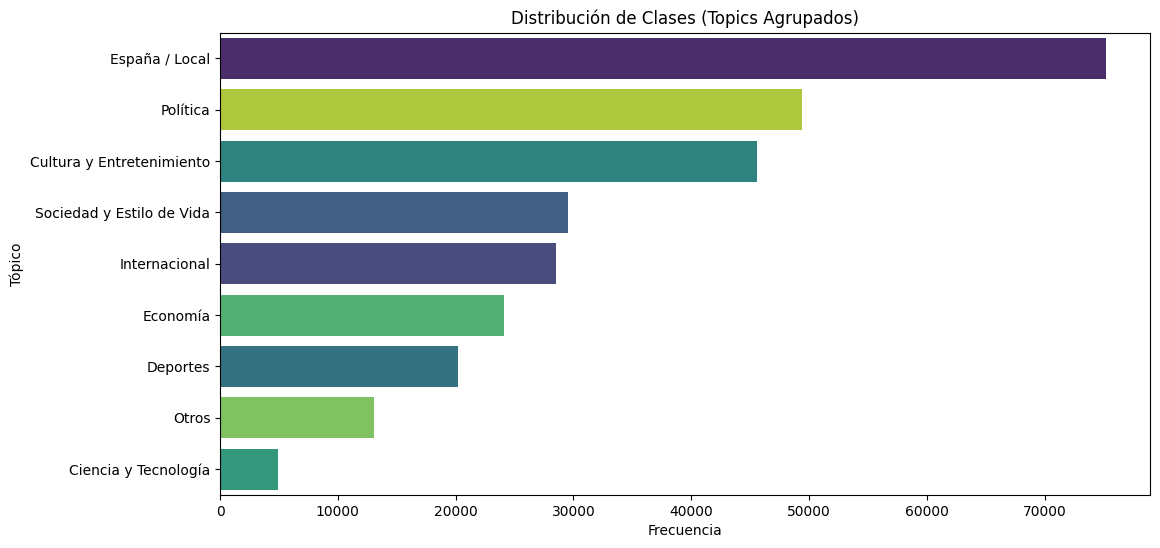

In [4]:
def map_topic(topic):
    topic = str(topic).lower()
    if any(k in topic for k in ['deporte', 'futbol', 'baloncesto', 'olimpico', 'champions', 'eurocopa', 'adrenalina']):
        return 'Deportes'
    elif any(k in topic for k in ['politica', 'congreso', 'opinion', 'genova', 'eldebate']):
        return 'Política'
    elif any(k in topic for k in ['economia', 'negocio', 'empleo', 'vivienda', 'finanzas', 'ahorro', 'mercado']):
        return 'Economía'
    elif any(k in topic for k in ['tecnologia', 'ciencia', 'motor', 'ciberpais', 'techie', 'digital']):
        return 'Ciencia y Tecnología'
    elif any(k in topic for k in ['cultura', 'cine', 'television', 'babelia', 'tentaciones', 'eps', 'icon', 'vinetas', 'arte', 'album']):
        return 'Cultura y Entretenimiento'
    elif any(k in topic for k in ['internacional', 'america', 'mexico', 'estados_unidos', 'colombia', 'argentina', 'mundo']):
        return 'Internacional'
    elif any(k in topic for k in ['sociedad', 'gente', 'estilo', 'viajero', 'salud', 'educacion', 'mamas', 'buenavida', 'planeta_futuro']):
        return 'Sociedad y Estilo de Vida'
    elif any(k in topic for k in ['ccaa', 'catalunya', 'madrid', 'valencia', 'paisvasco', 'galicia', 'andalucia', 'espana', 'cvalenciana', 'cat ']) or 'elpais actualidad' in topic:
        return 'España / Local'
    else:
        return 'Otros'

df['Topic_Grouped'] = df['Topic'].apply(map_topic)

print("Distribución de Tópicos Agrupados:")
print(df['Topic_Grouped'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Topic_Grouped', order=df['Topic_Grouped'].value_counts().index, palette='viridis', hue='Topic_Grouped', legend=False)
plt.title('Distribución de Clases (Topics Agrupados)')
plt.xlabel('Frecuencia')
plt.ylabel('Tópico')
plt.show()

## **PASO 2: LIMPIEZA ESTRUCTURAL DEL DATASET**

Antes de procesar el texto, se realiza una limpieza a nivel de registros:
- **Nulos y vacíos**: Se eliminan filas sin título o contenido.
- **Duplicados**: Se eliminan registros con mismo título + contenido.
- **Textos cortos** (< 100 caracteres en Content): Suelen ser registros malformados por errores de parseo del CSV original (campos con comas internas, saltos de línea, etc.).

In [5]:
# Eliminar nulos y vacíos
n_before = len(df)
df = df.dropna(subset=['Title', 'Content', 'Topic_Grouped']).copy()
df = df[(df['Title'].str.strip() != '') & (df['Content'].str.strip() != '')]
print(f"Nulos/vacíos eliminados: {n_before - len(df)}")

# Eliminar duplicados
n_before = len(df)
df = df.drop_duplicates(subset=['Title', 'Content'])
print(f"Duplicados eliminados: {n_before - len(df)}")

# Filtrar textos extremadamente cortos
n_before = len(df)
df = df[df['Content'].str.len() >= 100]
print(f"Textos cortos (< 100 chars) eliminados: {n_before - len(df)}")
print(f"\nRegistros tras limpieza estructural: {len(df)}")

Nulos/vacíos eliminados: 0
Duplicados eliminados: 1606
Textos cortos (< 100 chars) eliminados: 0

Registros tras limpieza estructural: 289039


## **PASO 3: FILTRO DE IDIOMA**

El dataset MLSUM, aunque procede de medios en español, puede contener artículos completos o fragmentos extensos en otros idiomas.

Se usa `langdetect` para detectar la lengua dominante de cada texto y descartar los no españoles. **Importante**: Un artículo en español que mencione equipos de la NBA o use anglicismos NO se descarta, porque `langdetect` evalúa la lengua dominante del texto completo, no palabras individuales.

Se aplica solo a textos ≥ 200 caracteres (en textos más cortos la detección es imprecisa).

In [6]:
def detect_language_safe(text):
    """Detecta idioma con fallback a 'unknown' si falla."""
    try:
        return langdetect_detect(text)
    except Exception:
        return 'unknown'

print(f"Detectando idioma en {len(df)} textos...")
tqdm.pandas(desc="Detectando idioma")

# Solo aplicar a textos suficientemente largos
mask_long = df['Content'].str.len() >= 200
languages = pd.Series('es', index=df.index)
languages[mask_long] = df.loc[mask_long, 'Content'].progress_apply(detect_language_safe)

# Mantener español + desconocido (beneficio de la duda)
mask_spanish = languages.isin(['es', 'unknown'])
n_removed = (~mask_spanish).sum()

print(f"\nTextos no españoles eliminados: {n_removed}")
if n_removed > 0:
    print("Distribución de idiomas eliminados:")
    print(languages[~mask_spanish].value_counts().head(10))

df = df[mask_spanish].copy()
print(f"Registros tras filtro de idioma: {len(df)}")

Detectando idioma en 289039 textos...


Detectando idioma:   0%|          | 0/289038 [00:00<?, ?it/s]


Textos no españoles eliminados: 3439
Distribución de idiomas eliminados:
en    3305
ca      57
pt      56
id      15
fr       5
it       1
Name: count, dtype: int64
Registros tras filtro de idioma: 285600


## **PASO 4: LIMPIEZA REGEX EXHAUSTIVA**

Se aplica una limpieza de texto en profundidad con expresiones regulares:
1. **Normalización Unicode**: Convierte comillas tipográficas, guiones largos y otros caracteres especiales a sus equivalentes estándar.
2. **Eliminación de URLs**: Tanto con protocolo (`http://...`) como dominios sueltos (`example.com`).
3. **Eliminación de emails**.
4. **Eliminación de tags HTML** residuales.
5. **Normalización de repeticiones**: `holaaaa` → `hola` (ruido de texto informal).
6. **Eliminación de números**: Las secuencias numéricas no aportan señal discriminante para la clasificación de tópicos.
7. **Filtrado de caracteres no alfabéticos**: Solo se conservan letras españolas (con tildes y ñ) y espacios.

In [7]:
def regex_clean(text):
    """Limpieza exhaustiva de texto con expresiones regulares."""
    text = str(text).lower()

    # Normalización Unicode (comillas tipográficas, guiones largos, etc.)
    text = unicodedata.normalize('NFKD', text)
    text = unicodedata.normalize('NFC', text)

    # URLs (incluyendo dominios sueltos)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+\.\w{2,4}(?:/\S*)?', '', text)

    # Emails
    text = re.sub(r'\S+@\S+', '', text)

    # Tags HTML
    text = re.sub(r'<.*?>', '', text)

    # Normalizar repeticiones (holaaaa → hola)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Eliminar secuencias numéricas
    text = re.sub(r'\d+', ' ', text)

    # Solo letras españolas y espacios
    text = re.sub(r'[^a-záéíóúñü\s]', ' ', text)

    # Colapsar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Unir Título + Contenido
print("Uniendo Título + Contenido...")
df['Texto_Completo'] = df['Title'] + " " + df['Content']

# Aplicar limpieza regex
print("Aplicando limpieza Regex exhaustiva...")
tqdm.pandas(desc="Limpieza Regex")
df['Regex_Content'] = df['Texto_Completo'].progress_apply(regex_clean)
print("¡Limpieza Regex completada!")

Uniendo Título + Contenido...
Aplicando limpieza Regex exhaustiva...


Limpieza Regex:   0%|          | 0/285600 [00:00<?, ?it/s]

¡Limpieza Regex completada!


## **PASO 5: PROCESAMIENTO NLP CON SPACY (LEMATIZACIÓN + NER)**

Este es el paso más crítico del preprocesamiento. Se utiliza el modelo pesado de spaCy (`es_core_news_lg`) con **NER activo** para:

### Reemplazo de Entidades Nombradas (NER)
Las entidades reconocidas se sustituyen por placeholders genéricos:
- `Pedro Sánchez`, `Pablo Casado` → `__PERSONA__`
- `Banco Central Europeo`, `Real Madrid` → `__ORGANIZACION__`
- `Madrid`, `Barcelona`, `España` → `__LUGAR__`

**¿Por qué?** Los nombres propios dominan el vocabulario TF-IDF pero son ruido para la clasificación de tópicos. "Pedro Sánchez" aparece tanto en noticias de Política como de Economía. Al reemplazar por el *tipo* de entidad, el modelo aprende que "la presencia de personas/organizaciones" es discriminante, sin depender de nombres específicos.

### Lematización
Reduce cada palabra a su forma base: `corrieron` → `correr`, `casas` → `casa`.

### Filtrado de Stopwords con Whitelist
Se eliminan stopwords **excepto** palabras cortas semánticamente importantes: `no`, `sí`, `ni`. Estas palabras alteran el significado de la frase y pueden ser discriminantes.

### Filtrado de Tokens Residuales
Se descartan tokens con < 3 caracteres (excepto los de la whitelist), tokens no alfabéticos y residuos numéricos.

In [8]:
# Cargar modelo spaCy (con descarga automática si no existe)
try:
    nlp = spacy.load('es_core_news_lg')
    print("[spaCy] Modelo 'es_core_news_lg' cargado correctamente.")
except OSError:
    print("[spaCy] Descargando modelo 'es_core_news_lg'...")
    from spacy.cli import download as spacy_download
    spacy_download("es_core_news_lg")
    nlp = spacy.load('es_core_news_lg')
    print("[spaCy] Modelo descargado y cargado correctamente.")

nlp.max_length = 2_000_000

# Mapeo de etiquetas NER → placeholders genéricos
NER_MAP = {
    'PER': '__PERSONA__',
    'ORG': '__ORGANIZACION__',
    'LOC': '__LUGAR__',
    'GPE': '__LUGAR__',
    'MISC': '__ENTIDAD__',
}

# Stopwords cortas que SÍ aportan significado semántico
STOPWORD_WHITELIST = {'no', 'sí', 'ni'}

def spacy_clean_batch(texts, batch_size=256):
    """Procesamiento NLP: lematización + reemplazo NER + filtrado."""
    cleaned_docs = []

    for doc in tqdm(
        nlp.pipe(texts, batch_size=batch_size, disable=["parser"]),
        total=len(texts),
        desc="Procesando NLP (lematización + NER)"
    ):
        # Identificar tokens que pertenecen a entidades NER
        ent_token_indices = {}
        for ent in doc.ents:
            for token in ent:
                ent_token_indices[token.i] = ent

        tokens = []
        processed_ents = set()

        for token in doc:
            if token.i in ent_token_indices:
                ent = ent_token_indices[token.i]
                ent_id = (ent.start, ent.end)
                if ent_id not in processed_ents:
                    processed_ents.add(ent_id)
                    placeholder = NER_MAP.get(ent.label_, '__ENTIDAD__')
                    tokens.append(placeholder)
            else:
                lemma = token.lemma_.lower()
                if token.is_stop and lemma not in STOPWORD_WHITELIST:
                    continue
                if token.is_punct or token.is_space:
                    continue
                if not token.is_alpha:
                    continue
                if len(lemma) < 3 and lemma not in STOPWORD_WHITELIST:
                    continue
                tokens.append(lemma)

        cleaned_docs.append(" ".join(tokens))
    return cleaned_docs

# Aplicar procesamiento NLP
print("Aplicando procesamiento spaCy (Lematización + NER)...")
texts_to_process = df['Regex_Content'].tolist()
df['Cleaned_Content'] = spacy_clean_batch(texts_to_process)

# Limpiar columnas intermedias
df = df.drop(columns=['Regex_Content', 'Texto_Completo'])

# Eliminar textos que quedaron vacíos
n_before = len(df)
df = df[df['Cleaned_Content'].str.strip() != '']
df = df.reset_index(drop=True)
print(f"Textos vacíos tras NLP eliminados: {n_before - len(df)}")

print(f"\n=== RESUMEN DEL PREPROCESAMIENTO ===")
print(f"Registros finales: {len(df)}")
print(f"\nDistribución de clases:")
print(df['Topic_Grouped'].value_counts())

display(df[['Title', 'Content', 'Cleaned_Content', 'Topic_Grouped']].head())

[spaCy] Modelo 'es_core_news_lg' cargado correctamente.
Aplicando procesamiento spaCy (Lematización + NER)...


Procesando NLP (lematización + NER):   0%|          | 0/285600 [00:00<?, ?it/s]

Textos vacíos tras NLP eliminados: 0

=== RESUMEN DEL PREPROCESAMIENTO ===
Registros finales: 285600

Distribución de clases:
Topic_Grouped
España / Local               75059
Política                     48370
Cultura y Entretenimiento    45162
Sociedad y Estilo de Vida    29504
Internacional                28430
Economía                     24115
Deportes                     20222
Otros                         9845
Ciencia y Tecnología          4893
Name: count, dtype: int64


,Title,Content,Cleaned_Content,Topic_Grouped
0,¿Quién ganó en las campanadas?,"De momento, no podemos responder a la pregunta...",ganar campanada momento no responder pregunta ...,España / Local
1,Las aerolíneas denuncian retrasos en Barajas p...,Los vuelos han venido registrando este viernes...,aerolínea denunciar retraso __LUGAR__ provocad...,España / Local
2,Turquía reclama a Italia la devolución de los ...,El Gobierno turco ha anunciado que emprenderá ...,__LUGAR__ reclamar __LUGAR__ devolución resto ...,España / Local
3,El autor del tiroteo de Finlandia escogió a su...,La policía de Finlandia ha informado este vier...,autor __ENTIDAD__ escoger víctima policía poli...,Internacional
4,Descubierto un agujero vertical en la Luna,"""Hemos descubierto un agujero vertical en la L...",descubierto agujero vertical __LUGAR__ descubr...,Sociedad y Estilo de Vida


## **SPLIT Y REPRESENTACIÓN CON TF-IDF**

Se codifican las etiquetas con `LabelEncoder`, se divide el dataset en **80% entrenamiento / 20% test** (estratificado para mantener la proporción de clases), y se vectoriza el texto con **TF-IDF**:
- **max_features=50.000**: Limita el vocabulario a las 50K features más relevantes.
- **ngram_range=(1,2)**: Incluye unigramas y bigramas para capturar contexto local (ej: "banco central" vs "banco" solo).

In [9]:
print("1. Transformando etiquetas a formato numérico...")
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Topic_Grouped'])

print("Mapeo de clases:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"{idx}: {cls}")

print("\n2. Dividiendo el dataset (80% Entrenamiento, 20% Prueba)...")
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Content'],
    df['Target'],
    test_size=0.2,
    random_state=42,
    stratify=df['Target']
)
print(f"Set de Entrenamiento: {len(X_train)} muestras")
print(f"Set de Prueba: {len(X_test)} muestras")

print("\n3. Vectorizando el texto con TF-IDF...")
vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Dimensiones de la matriz TF-IDF (Entrenamiento): {X_train_tfidf.shape}")

1. Transformando etiquetas a formato numérico...
Mapeo de clases:
0: Ciencia y Tecnología
1: Cultura y Entretenimiento
2: Deportes
3: Economía
4: España / Local
5: Internacional
6: Otros
7: Política
8: Sociedad y Estilo de Vida

2. Dividiendo el dataset (80% Entrenamiento, 20% Prueba)...
Set de Entrenamiento: 228480 muestras
Set de Prueba: 57120 muestras

3. Vectorizando el texto con TF-IDF...
Dimensiones de la matriz TF-IDF (Entrenamiento): (228480, 30000)


### **PREPARAR MATRICES PARA GPU**

In [10]:
print("Pasando matrices a 32 bits y ordenando índices...")
X_train_tfidf = X_train_tfidf.astype(np.float32)
X_train_tfidf.sort_indices()
X_test_tfidf = X_test_tfidf.astype(np.float32)
X_test_tfidf.sort_indices()
print("Datos listos para el entrenamiento!")

Pasando matrices a 32 bits y ordenando índices...
Datos listos para el entrenamiento!


## **ENTRENAMIENTO DEL MODELO XGBOOST**

Se configura un `XGBClassifier` multiclase con:
- **30.000 estimadores** máximos con **early stopping** (20 rondas sin mejora).
- **`tree_method='hist'`** + **`device='cuda'`** para aceleración por GPU.
- Parámetros de regularización: `max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8`.

Iniciando el entrenamiento del modelo XGBoost con GPU
[0]	validation_0-mlogloss:2.05630	validation_1-mlogloss:2.05723
[5]	validation_0-mlogloss:1.72307	validation_1-mlogloss:1.72798
[10]	validation_0-mlogloss:1.51482	validation_1-mlogloss:1.52212
[15]	validation_0-mlogloss:1.36412	validation_1-mlogloss:1.37365
[20]	validation_0-mlogloss:1.24886	validation_1-mlogloss:1.26041
[25]	validation_0-mlogloss:1.15675	validation_1-mlogloss:1.16977
[30]	validation_0-mlogloss:1.08244	validation_1-mlogloss:1.09713
[35]	validation_0-mlogloss:1.02041	validation_1-mlogloss:1.03664
[40]	validation_0-mlogloss:0.96812	validation_1-mlogloss:0.98580
[45]	validation_0-mlogloss:0.92428	validation_1-mlogloss:0.94340
[50]	validation_0-mlogloss:0.88575	validation_1-mlogloss:0.90625
[55]	validation_0-mlogloss:0.85223	validation_1-mlogloss:0.87415
[60]	validation_0-mlogloss:0.82287	validation_1-mlogloss:0.84613
[65]	validation_0-mlogloss:0.79740	validation_1-mlogloss:0.82195
[70]	validation_0-mlogloss:0.77457	val

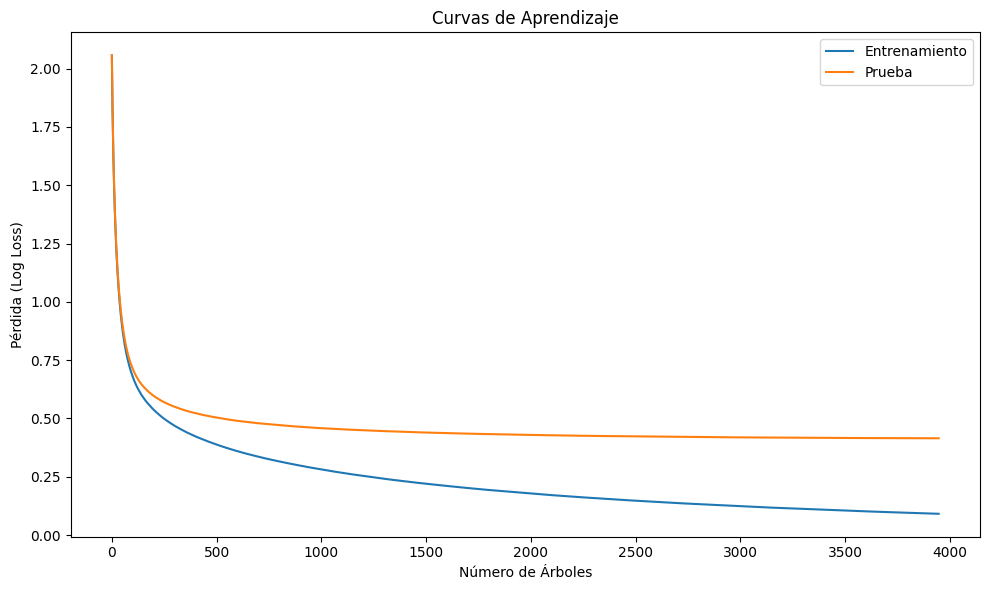

In [11]:
print("Iniciando el entrenamiento del modelo XGBoost con GPU")
xgb_model = xgb.XGBClassifier(
    n_estimators=30000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    random_state=42,
    early_stopping_rounds=20,
    n_jobs=-1,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
)

evals = [(X_train_tfidf, y_train), (X_test_tfidf, y_test)]
start_time = time.time()

xgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=evals,
    verbose=5,
)

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed:.2f} segundos")

# Curvas de aprendizaje
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Entrenamiento')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Prueba')
plt.legend()
plt.ylabel('Pérdida (Log Loss)')
plt.xlabel('Número de Árboles')
plt.title('Curvas de Aprendizaje')
plt.tight_layout()
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/curvas_aprendizaje_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

## **GUARDADO DEL MODELO Y ARTEFACTOS**

In [12]:
os.makedirs('artefactos', exist_ok=True)
xgb_model.save_model('artefactos/xgboost_topic_classifier.pkl')
joblib.dump(vectorizer, 'artefactos/tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'artefactos/label_encoder.pkl')
print("Modelo y artefactos guardados en 'artefactos/'")

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [02:50:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


Modelo y artefactos guardados en 'artefactos/'


## **EVALUACIÓN DEL MODELO**

Realizando predicciones en el conjunto de prueba...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:774: UserWarning: [02:50:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



--- REPORTE DE CLASIFICACIÓN ---
                           precision    recall  f1-score   support

     Ciencia y Tecnología       0.79      0.64      0.71       979
Cultura y Entretenimiento       0.82      0.88      0.85      9032
                 Deportes       0.99      0.99      0.99      4044
                 Economía       0.85      0.86      0.85      4823
           España / Local       0.86      0.89      0.88     15012
            Internacional       0.84      0.88      0.86      5686
                    Otros       0.84      0.64      0.72      1969
                 Política       0.89      0.85      0.87      9674
Sociedad y Estilo de Vida       0.80      0.74      0.77      5901

                 accuracy                           0.86     57120
                macro avg       0.85      0.82      0.83     57120
             weighted avg       0.86      0.86      0.86     57120

Generando Matriz de Confusión...


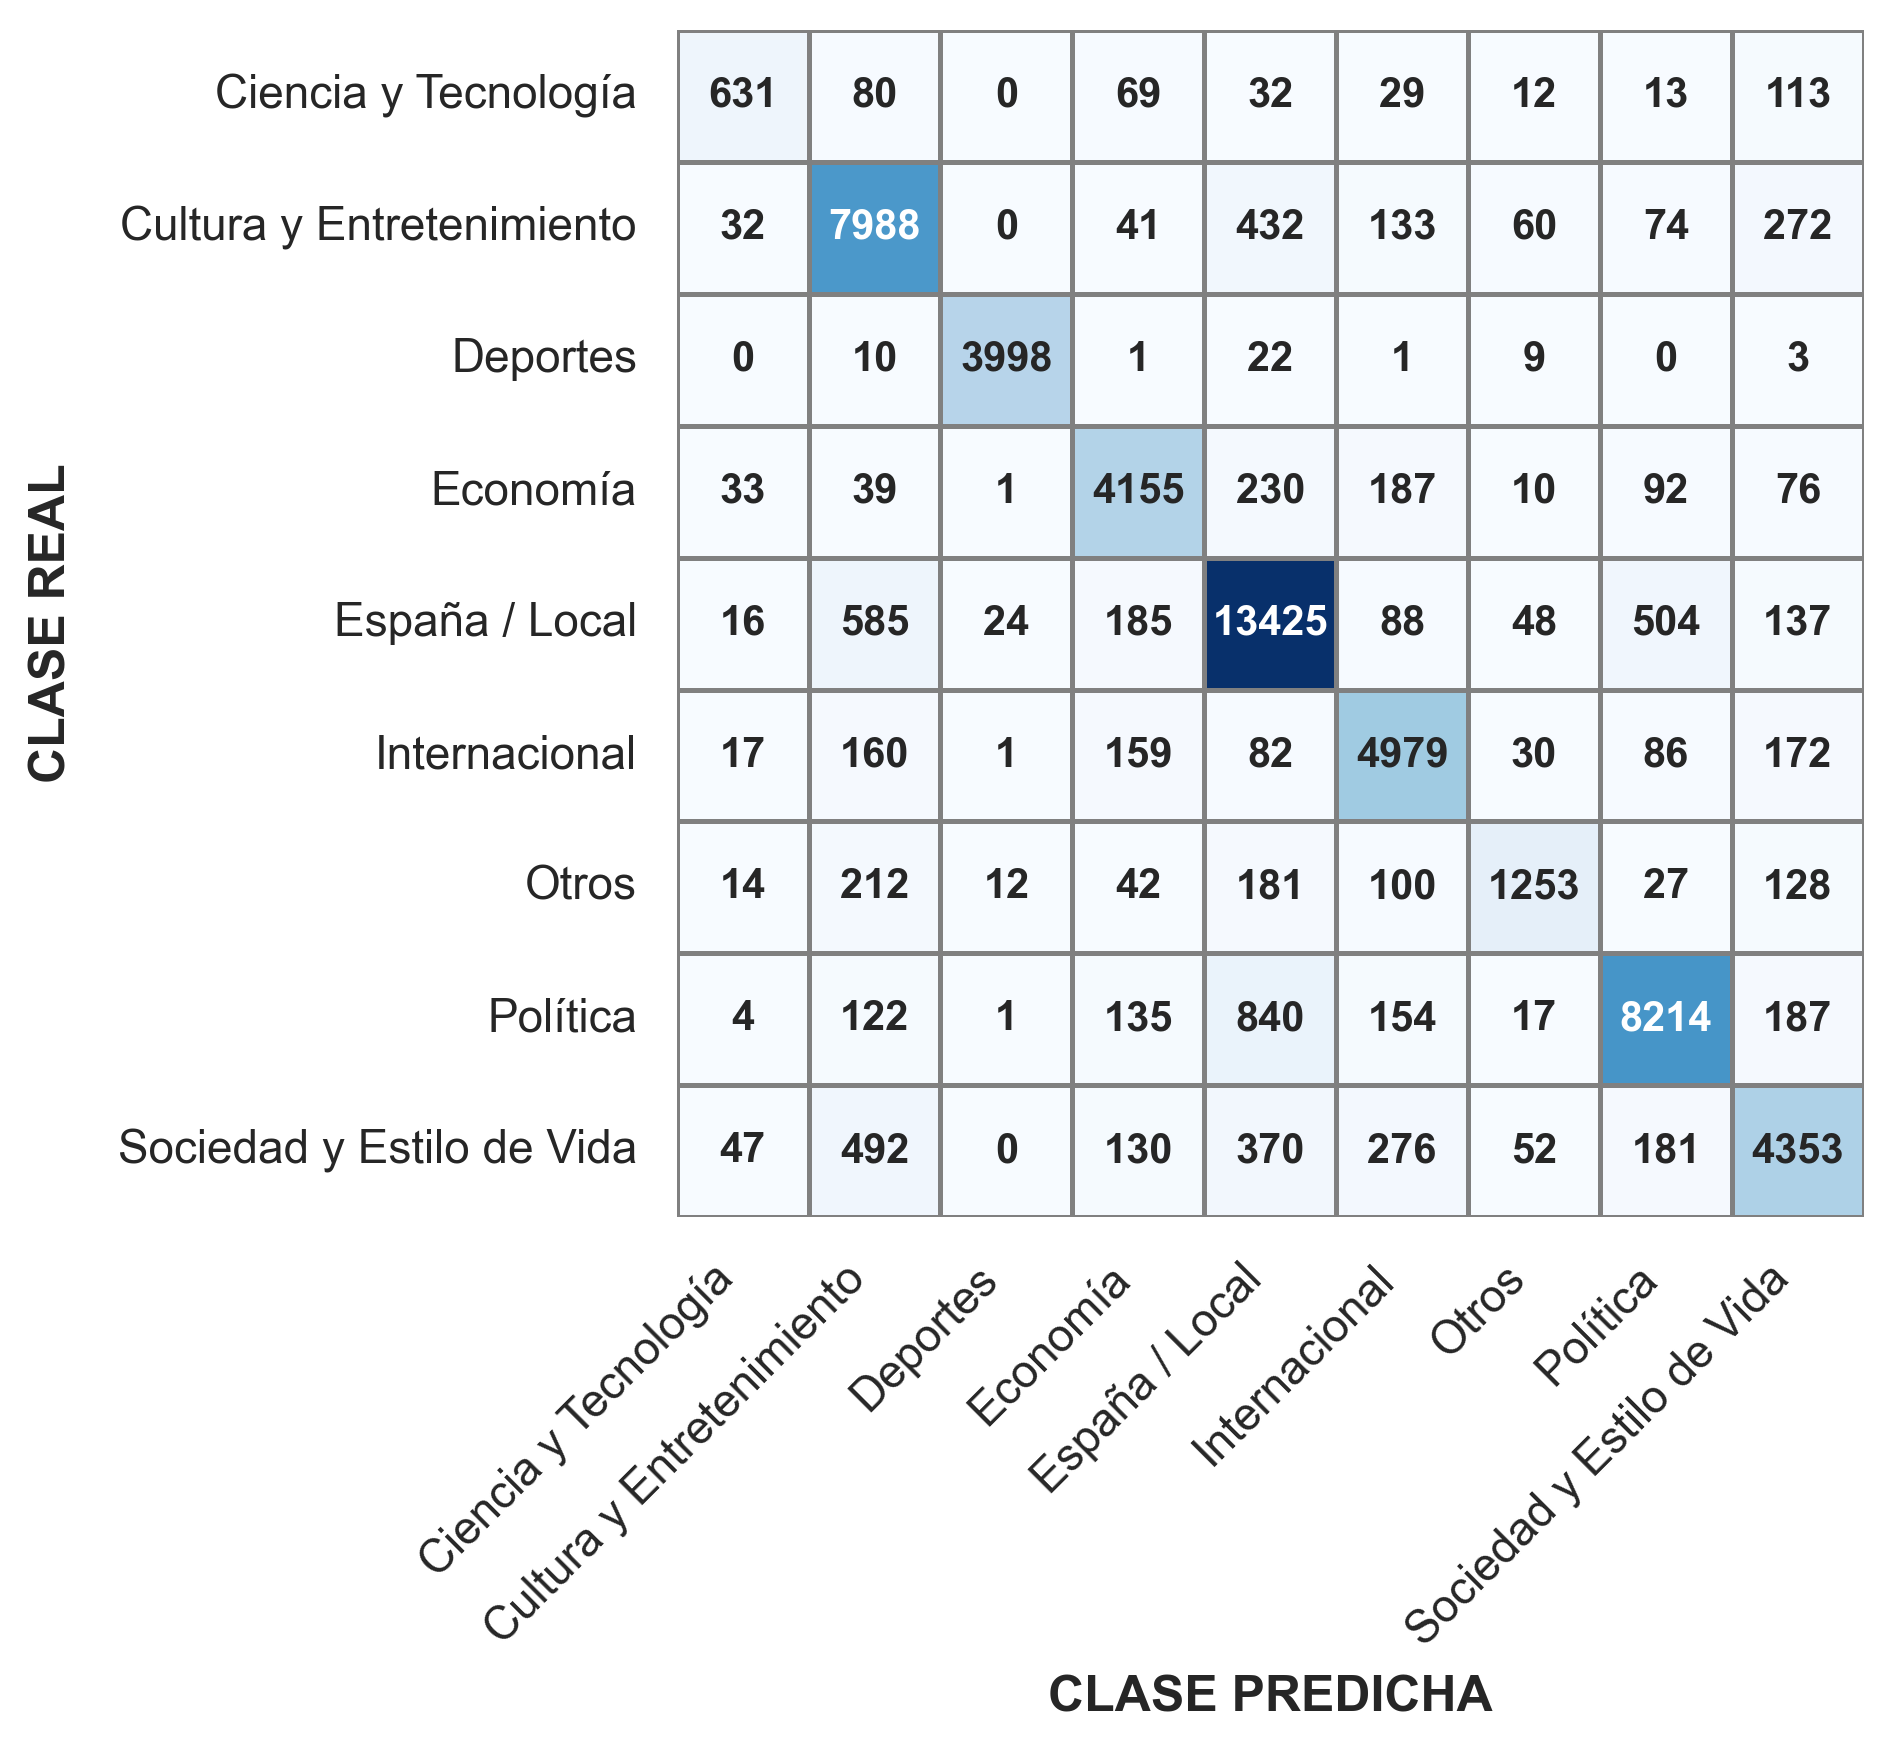

In [13]:
print("Realizando predicciones en el conjunto de prueba...")
y_pred = xgb_model.predict(X_test_tfidf)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("Generando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)

TAMANO_LABELS = 12
TAMANO_CLASES = 12
TAMANO_NUMEROS = 10

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['axes.labelsize'] = TAMANO_LABELS
mpl.rcParams['xtick.labelsize'] = TAMANO_CLASES
mpl.rcParams['ytick.labelsize'] = TAMANO_CLASES
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
    annot_kws={"size": TAMANO_NUMEROS, "fontweight": "bold", "family": "sans-serif"},
    linewidths=0.8, linecolor='gray', cbar=False, square=True)
ax.set_xlabel('CLASE PREDICHA', labelpad=5, fontweight='bold')
ax.set_ylabel('CLASE REAL', labelpad=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figuras/matriz_confusion_topic_classifier.png', dpi=300, bbox_inches='tight')
plt.show()

### **CELDA DE INFERENCIA PARA PRODUCCIÓN**

Pipeline completo: texto crudo → limpieza regex → spaCy (NER + lematización) → TF-IDF → predicción.

In [14]:
print("Cargando modelo y artefactos desde disco...")
modelo_prod = xgb.XGBClassifier()
modelo_prod.load_model('artefactos/xgboost_topic_classifier.pkl')
vectorizador_prod = joblib.load('artefactos/tfidf_vectorizer.pkl')
encoder_prod = joblib.load('artefactos/label_encoder.pkl')

def clasificar_nueva_noticia(titulo, contenido):
    """Pipeline completo para clasificar un texto en crudo."""
    texto_combinado = titulo + " " + contenido
    texto_regex = regex_clean(texto_combinado)
    texto_nlp = spacy_clean_batch([texto_regex], batch_size=1)[0]
    texto_tfidf = vectorizador_prod.transform([texto_nlp])
    texto_tfidf = texto_tfidf.astype(np.float32)
    texto_tfidf.sort_indices()
    clase_numerica = modelo_prod.predict(texto_tfidf)
    return encoder_prod.inverse_transform(clase_numerica)[0]

# Prueba
titulo_prueba = "Bajada histórica de tipos del BCE"
contenido_prueba = "El Banco Central Europeo anuncia una bajada histórica de los tipos de interés. Esta medida busca estimular la concesión de hipotecas y frenar la inflación en el mercado de la vivienda."

print("\nProcesando noticia de prueba...")
categoria_predicha = clasificar_nueva_noticia(titulo_prueba, contenido_prueba)

print("-" * 50)
print("RESULTADO DEL MODELO:")
print("-" * 50)
print(f"TÍTULO: {titulo_prueba}")
print(f"CONTENIDO: {contenido_prueba}")
print(f"PREDICCIÓN: {categoria_predicha.upper()}")

Cargando modelo y artefactos desde disco...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py:1125: UserWarning: [02:50:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1511: Unknown file format: `pkl`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)



Procesando noticia de prueba...


Procesando NLP (lematización + NER):   0%|          | 0/1 [00:00<?, ?it/s]

--------------------------------------------------
RESULTADO DEL MODELO:
--------------------------------------------------
TÍTULO: Bajada histórica de tipos del BCE
CONTENIDO: El Banco Central Europeo anuncia una bajada histórica de los tipos de interés. Esta medida busca estimular la concesión de hipotecas y frenar la inflación en el mercado de la vivienda.
PREDICCIÓN: ECONOMÍA
